In [12]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
#from mobilevit import *

In [13]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,  
    
)

In [14]:
train_generator = train_datagen.flow_from_directory(
    'dataset/Train',
    target_size=(256, 256),  
    batch_size=32,
    class_mode='categorical'
)

Found 973 images belonging to 5 classes.


In [15]:
valid_datagen = ImageDataGenerator(
    rescale=1.0/255)

In [16]:
valid_generator = valid_datagen.flow_from_directory(
    'dataset/Test',
    target_size=(256, 256),  
    batch_size=32,
    class_mode='categorical'
)

Found 292 images belonging to 5 classes.


In [17]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
from tensorflow.keras import layers as L


def inverted_residual_block(inputs, num_filters, strides=1, expansion_ratio=1):
    x = L.Conv2D(
        filters=expansion_ratio*inputs.shape[-1],
        kernel_size=1,
        padding="same",
        use_bias=False
    )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    x = L.DepthwiseConv2D(
        kernel_size=3,
        strides=strides,
        padding="same",
        use_bias=False
    )(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    ## Point-Wise Convolution
    x = L.Conv2D(
        filters=num_filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)
    x = L.BatchNormalization()(x)

    ## Residual Connection
    if strides == 1 and (inputs.shape == x.shape):
        return L.Add()([inputs, x])
    return x


def mlp(x, mlp_dim, dim, dropout_rate=0.1):
    x = L.Dense(mlp_dim, activation="swish")(x)
    x = L.Dropout(dropout_rate)(x)
    x = L.Dense(dim)(x)
    x = L.Dropout(dropout_rate)(x)
    return x

def transformer_encoder(x, num_heads, dim, mlp_dim):
    skip_1 = x
    x = L.LayerNormalization()(x)
    x = L.MultiHeadAttention(
        num_heads=num_heads, key_dim=dim
    )(x, x)
    x = L.Add()([x, skip_1])

    skip_2 = x
    x = L.LayerNormalization()(x)
    x = mlp(x, mlp_dim, dim)
    x = L.Add()([x, skip_2])

    return x

def mobile_vit_block(inputs, num_filters, dim, patch_size=2, num_layers=1):
    B, H, W, C = inputs.shape

    ## 3x3 conv
    x = L.Conv2D(
        filters=C,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    ## 1x1 conv: d-dimension
    x = L.Conv2D(
        filters=dim,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    ## Reshape x to flattened patches
    P = patch_size*patch_size
    N = int(H*W//P)
    x = L.Reshape((P, N, dim))(x)

    ## Transformr Encoder
    for _ in range(num_layers):
        x = transformer_encoder(x, 1, dim, dim*2)

    ## Reshape
    x = L.Reshape((H, W, dim))(x)

    ## 1x1 conv: C-dimension
   # x = L.Conv2D(
   #     filters=C,
   #     kernel_size=1,
   #     padding="same",
   #     use_bias=False
   # )(inputs)
   # x = L.BatchNormalization()(x)
   # x = L.Activation("swish")(x)

    ## Concatenation
    x = L.Concatenate()([x, inputs])

    ## 3x3 conv
    x = L.Conv2D(
        filters=num_filters,
        kernel_size=3,
        padding="same",
        use_bias=False
    )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    return x

def MobileViT(input_shape, num_channels, dim, expansion_ratio, num_layers=[2, 4, 3], num_classes=1000):
    inputs = L.Input(input_shape)

    x = L.Conv2D(
        filters=num_channels[0],
        kernel_size=3,
        strides=2,
        padding="same",
        use_bias=False
    )(inputs)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)
    x = inverted_residual_block(x, num_channels[1], strides=1, expansion_ratio=expansion_ratio)

    ## Stage 1
    x = inverted_residual_block(x, num_channels[2], strides=2, expansion_ratio=expansion_ratio)
    x = inverted_residual_block(x, num_channels[3], strides=1, expansion_ratio=expansion_ratio)
    x = inverted_residual_block(x, num_channels[4], strides=1, expansion_ratio=expansion_ratio)

    x = inverted_residual_block(x, num_channels[5], strides=2, expansion_ratio=expansion_ratio)
    x = mobile_vit_block(x, num_channels[6], dim[0], num_layers=num_layers[0])

    x = inverted_residual_block(x, num_channels[7], strides=2, expansion_ratio=expansion_ratio)
    x = mobile_vit_block(x, num_channels[8], dim[1], num_layers=num_layers[1])

    #x = inverted_residual_block(x, num_channels[9], strides=2, expansion_ratio=expansion_ratio)
    #x = mobile_vit_block(x, num_channels[10], dim[2], num_layers=num_layers[2])
    x = L.Conv2D(
        filters=num_channels[11],
        kernel_size=1,
        padding="same",
        use_bias=False
    )(x)
    x = L.BatchNormalization()(x)
    x = L.Activation("swish")(x)

    x = L.GlobalAveragePooling2D()(x)
    outputs = L.Dense(num_classes, activation="softmax")(x)

    model = tf.keras.models.Model(inputs, outputs)
    return model


def MobileViT_S(input_shape, num_classes):
    num_channels = [16, 32, 64, 64, 64, 96, 144, 128, 192, 160, 240, 640]
    dim = [144, 192, 240]
    expansion_ratio = 4
    print(input_shape)

    return MobileViT(
        input_shape,
        num_channels,
        dim,
        expansion_ratio,
        num_classes=num_classes
        )

In [18]:
model = MobileViT_S(input_shape=(256, 256, 3), num_classes=5)  # Updated input_shape to (224, 224, 3)
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)
checkpoint = ModelCheckpoint(
            "model_weights.h5",  
            monitor='val_accuracy',
            verbose=1,
            save_best_only=True,
            mode='max'
        )
callbacks_list = [checkpoint]
model.summary()

(256, 256, 3)
Model: "model_3"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_4 (InputLayer)        [(None, 256, 256, 3)]        0         []                            
                                                                                                  
 conv2d_60 (Conv2D)          (None, 128, 128, 16)         432       ['input_4[0][0]']             
                                                                                                  
 batch_normalization_78 (Ba  (None, 128, 128, 16)         64        ['conv2d_60[0][0]']           
 tchNormalization)                                                                                
                                                                                                  
 activation_60 (Activation)  (None, 128, 128, 16)         0         ['batch_no

In [19]:
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=valid_generator,
    callbacks=callbacks_list
)

Epoch 1/50
31/31 [==============================] - ETA: 0s - loss: 1.6445 - accuracy: 0.2271
Epoch 1: val_accuracy improved from -inf to 0.20548, saving model to model_weights.h5
31/31 [==============================] - 187s 6s/step - loss: 1.6445 - accuracy: 0.2271 - val_loss: 1.6109 - val_accuracy: 0.2055
Epoch 2/50
31/31 [==============================] - ETA: 0s - loss: 1.6081 - accuracy: 0.2271
Epoch 2: val_accuracy did not improve from 0.20548
31/31 [==============================] - 183s 6s/step - loss: 1.6081 - accuracy: 0.2271 - val_loss: 1.6118 - val_accuracy: 0.2055
Epoch 3/50
31/31 [==============================] - ETA: 0s - loss: 1.6124 - accuracy: 0.2374
Epoch 3: val_accuracy did not improve from 0.20548
31/31 [==============================] - 178s 6s/step - loss: 1.6124 - accuracy: 0.2374 - val_loss: 1.6143 - val_accuracy: 0.2055
Epoch 4/50
31/31 [==============================] - ETA: 0s - loss: 1.6192 - accuracy: 0.1963
Epoch 4: val_accuracy did not improve from 0.2

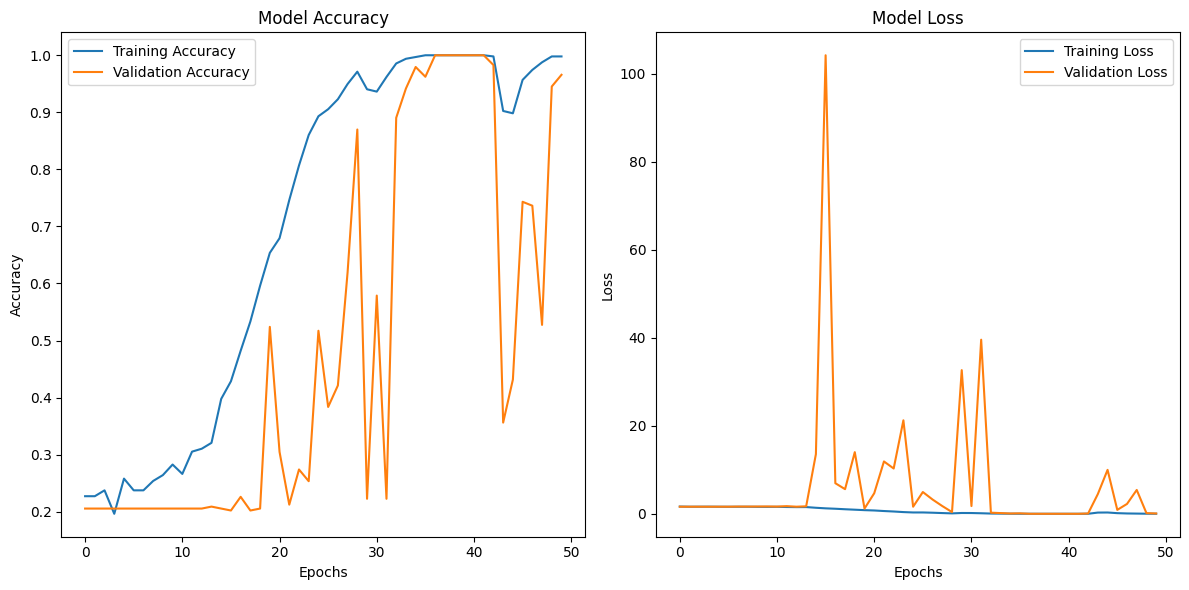

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()